# CIFAR-10 NTSC v2 — Final Testing

Load the saved NTSC v2 CNN and SVM, then report official CIFAR-10 test accuracy. This notebook does not fit or select models.


In [33]:
import os
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

SEED = 30092026

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf

# Hindari TensorFlow langsung mengalokasikan hampir seluruh VRAM.
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

print("GPU:", gpus)

tf.random.set_seed(SEED)

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load Official CIFAR-10 Test Set

In [34]:
_, (X_test, y_test) = cifar10.load_data()

y_test = y_test.flatten()

labels = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

classes_name = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

print("Original RGB X_test:", X_test.shape)
print("y_test             :", y_test.shape)

Original RGB X_test: (10000, 32, 32, 3)
y_test             : (10000,)


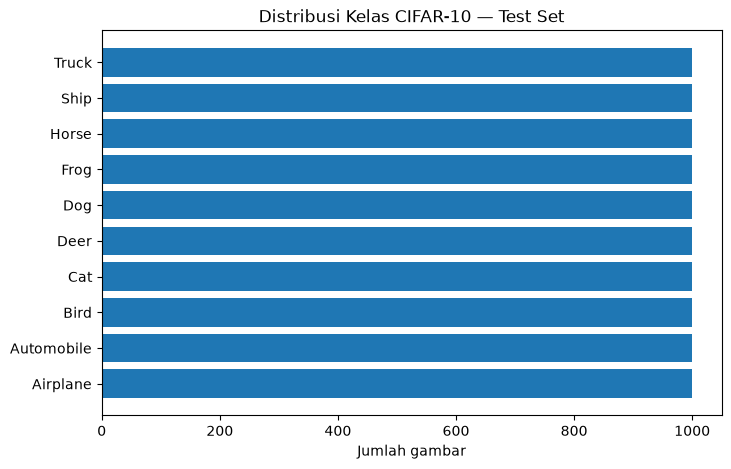

In [35]:
classes, counts = np.unique(
    y_test,
    return_counts=True
)

plt.figure(figsize=(8, 5))
plt.barh(
    classes_name,
    counts
)
plt.title(
    "Distribusi Kelas CIFAR-10 — Test Set"
)
plt.xlabel("Jumlah gambar")
plt.show()

## 2. Preprocessing Grayscale NTSC

Preprocessing harus identik dengan NTSC Training:

```text
NTSC = 0.299R + 0.587G + 0.114B
```

kemudian normalisasi ke `[0, 1]`.

In [36]:
def rgb_to_ntsc_grayscale(images):
    images = images.astype("float32")
    gray = (
        0.299 * images[..., 0]
        + 0.587 * images[..., 1]
        + 0.114 * images[..., 2]
    )
    return gray[..., np.newaxis]

X_test = rgb_to_ntsc_grayscale(
    X_test
) / 255.0

y_cat_test = to_categorical(
    y_test,
    10
)

print("NTSC X_test :", X_test.shape)
print("y_cat_test  :", y_cat_test.shape)

assert X_test.shape == (10000, 32, 32, 1)

NTSC X_test : (10000, 32, 32, 1)
y_cat_test  : (10000, 10)


## 3. Load Grayscale NTSC CNN dan SVM

In [37]:
CNN_MODEL_PATH = "cifar10_ntsc_cnn_v2.keras"
SVM_MODEL_PATH = "cifar10_ntsc_svm_v2.joblib"

if not os.path.exists(CNN_MODEL_PATH):
    raise FileNotFoundError(
        f"{CNN_MODEL_PATH} tidak ditemukan. "
        "Jalankan notebook training terlebih dahulu."
    )

if not os.path.exists(SVM_MODEL_PATH):
    raise FileNotFoundError(
        f"{SVM_MODEL_PATH} tidak ditemukan. "
        "Jalankan notebook training terlebih dahulu."
    )

# Bersihkan session TensorFlow lama agar penggunaan VRAM lebih aman.
tf.keras.backend.clear_session()

# CNN hanya digunakan untuk inference / feature extraction.
cnn_model = load_model(
    CNN_MODEL_PATH,
    compile=False
)

# SVM Pipeline berisi StandardScaler + trained RBF-SVM.
svm_model = joblib.load(
    SVM_MODEL_PATH
)

print("CNN berhasil dimuat dari:")
print(CNN_MODEL_PATH)

print("\nSVM berhasil dimuat dari:")
print(SVM_MODEL_PATH)

print("\nCNN summary:")
cnn_model.summary()

print("\nSVM pipeline:")
print(svm_model)

CNN berhasil dimuat dari:
cifar10_ntsc_cnn_v2.keras

SVM berhasil dimuat dari:
cifar10_ntsc_svm_v2.joblib

CNN summary:


Model: "custom_cifar10_ntsc_residual_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │        576 │ input_image[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 32, 32,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 32, 32,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 32, 32,    │     36,864 │ stem_relu[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 32, 32,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 32, 32,    │     36,864 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 32, 32,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 64)               │            │ stem_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_out   │ (None, 32, 32,    │          0 │ stage1_block1_ad… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv1 │ (None, 32, 32,    │     36,864 │ stage1_block1_ou… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn1   │ (None, 32, 32,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_relu1 │ (None, 32, 32,    │          0 │ stage1_block2_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv2 │ (None, 32, 32,    │     36,864 │ stage1_block2_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn2   │ (None, 32, 32,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_add   │ (None, 32, 32,    │          0 │ stage1_block2_bn

 Total params: 11,446,602 (43.67 MB)

 Trainable params: 11,435,978 (43.62 MB)

 Non-trainable params: 10,624 (41.50 KB)


SVM pipeline:
Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=10, cache_size=2048, gamma=0.001))])


# 4. Feature Map Extraction pada NTSC Test Image

Menampilkan feature maps dari satu unseen Grayscale NTSC test image.

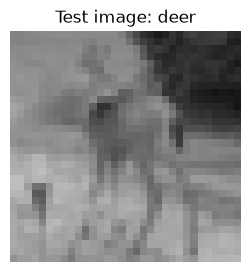

stem_relu: (1, 32, 32, 64)


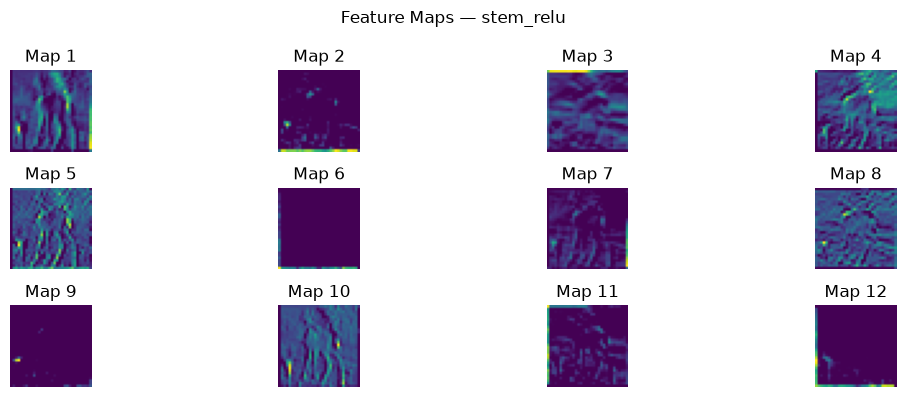

stage2_block2_out: (1, 16, 16, 128)


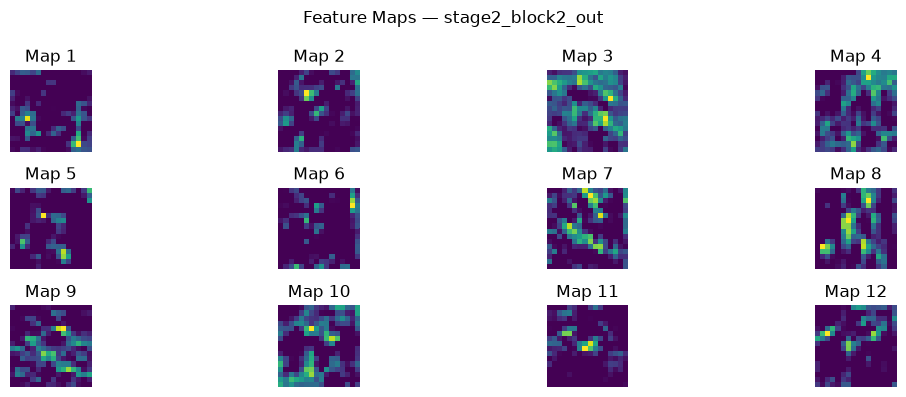

stage3_block2_out: (1, 8, 8, 256)


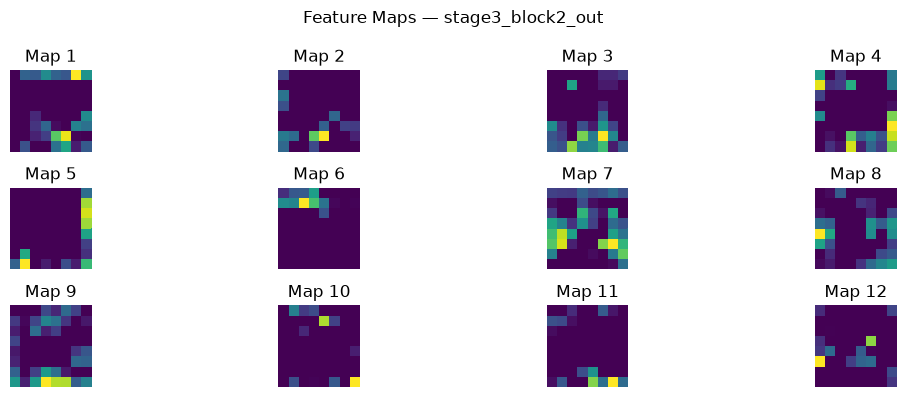

feature_map: (1, 4, 4, 512)


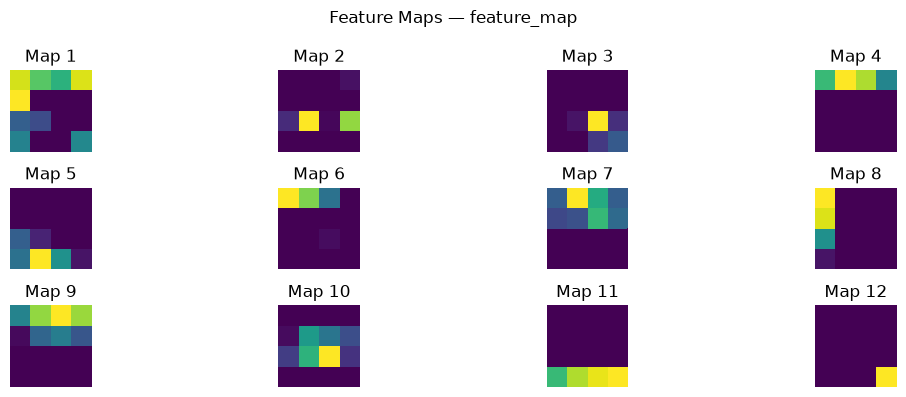

In [38]:
FEATURE_MAP_LAYERS = [
    "stem_relu",
    "stage2_block2_out",
    "stage3_block2_out",
    "feature_map"
]

feature_map_model = Model(
    inputs=cnn_model.input,
    outputs=[
        cnn_model.get_layer(name).output
        for name in FEATURE_MAP_LAYERS
    ],
    name="ntsc_feature_map_extractor"
)

sample_index = 100
sample_image = X_test[
    sample_index:sample_index + 1
]

feature_maps = feature_map_model.predict(
    sample_image,
    verbose=0
)

plt.figure(figsize=(3, 3))
plt.imshow(sample_image[0, :, :, 0], cmap="gray", vmin=0.0, vmax=1.0)
plt.title(
    f"Test image: "
    f"{labels[y_test[sample_index]]}"
)
plt.axis("off")
plt.show()

for layer_name, fmap in zip(
    FEATURE_MAP_LAYERS,
    feature_maps
):
    n_show = min(
        12,
        fmap.shape[-1]
    )

    print(
        f"{layer_name}: {fmap.shape}"
    )

    plt.figure(figsize=(12, 4))

    for i in range(n_show):
        plt.subplot(
            3,
            4,
            i + 1
        )
        plt.imshow(
            fmap[0, :, :, i],
            cmap="viridis"
        )
        plt.title(
            f"Map {i + 1}"
        )
        plt.axis("off")

    plt.suptitle(
        f"Feature Maps — {layer_name}"
    )
    plt.tight_layout()
    plt.show()

## 5. Baseline: Evaluasi NTSC CNN Softmax

CNN Softmax digunakan sebagai pembanding.

Hasil utama eksperimen tetap **NTSC CNN feature extraction + SVM**.

In [39]:
cnn_probability = cnn_model.predict(
    X_test,
    batch_size=128,
    verbose=1
)

cnn_prediction = np.argmax(
    cnn_probability,
    axis=1
)

cnn_accuracy = accuracy_score(
    y_test,
    cnn_prediction
)

print(
    f"CNN test accuracy: "
    f"{cnn_accuracy * 100:.2f}%"
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step
CNN test accuracy: 90.60%


# 6. Extract NTSC CNN Features untuk Seluruh Test Set

SVM menerima output layer `svm_features`, yaitu 512-dimensional vector dari Grayscale NTSC CNN.

In [40]:
feature_extractor = Model(
    inputs=cnn_model.input,
    outputs=cnn_model.get_layer(
        "svm_features"
    ).output,
    name="ntsc_cnn_feature_extractor"
)

X_test_features = feature_extractor.predict(
    X_test,
    batch_size=128,
    verbose=1
)

print(
    "Original test shape:",
    X_test.shape
)

print(
    "Extracted feature shape:",
    X_test_features.shape
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step
Original test shape: (10000, 32, 32, 1)
Extracted feature shape: (10000, 512)


# 7. Klasifikasi RBF-SVM pada NTSC CNN Features

In [41]:
svm_prediction = svm_model.predict(X_test_features)
svm_accuracy = accuracy_score(y_test, svm_prediction)
print("NTSC CNN softmax test accuracy:", f"{cnn_accuracy:.4%}")
print("NTSC CNN features + SVM test accuracy:", f"{svm_accuracy:.4%}")
print("Optional individual >95% milestone:", "PASS" if svm_accuracy > 0.95 else "NOT YET")

NTSC CNN softmax test accuracy: 90.6000%
NTSC CNN features + SVM test accuracy: 90.6900%
Optional individual >95% milestone: NOT YET


## 8. Classification Report SVM

In [42]:
print(
    classification_report(
        y_test,
        svm_prediction,
        target_names=labels,
        digits=4
    )
)

              precision    recall  f1-score   support

    airplane     0.9387    0.9190    0.9288      1000
  automobile     0.9584    0.9680    0.9632      1000
        bird     0.8640    0.8640    0.8640      1000
         cat     0.8022    0.8110    0.8066      1000
        deer     0.8940    0.8940    0.8940      1000
         dog     0.8522    0.8420    0.8471      1000
        frog     0.9187    0.9270    0.9228      1000
       horse     0.9513    0.9370    0.9441      1000
        ship     0.9484    0.9560    0.9522      1000
       truck     0.9416    0.9510    0.9463      1000

    accuracy                         0.9069     10000
   macro avg     0.9070    0.9069    0.9069     10000
weighted avg     0.9070    0.9069    0.9069     10000



## 9. Perbandingan NTSC CNN vs NTSC CNN Features + SVM

In [43]:
comparison = pd.DataFrame({
    "Classifier": [
        "CNN Softmax",
        "SVM on CNN Features"
    ],
    "Test Accuracy": [
        cnn_accuracy,
        svm_accuracy
    ]
})

display(comparison)

,Classifier,Test Accuracy
0,CNN Softmax,0.9060
1,SVM on CNN Features,0.9069


## 10. Confusion Matrix — SVM

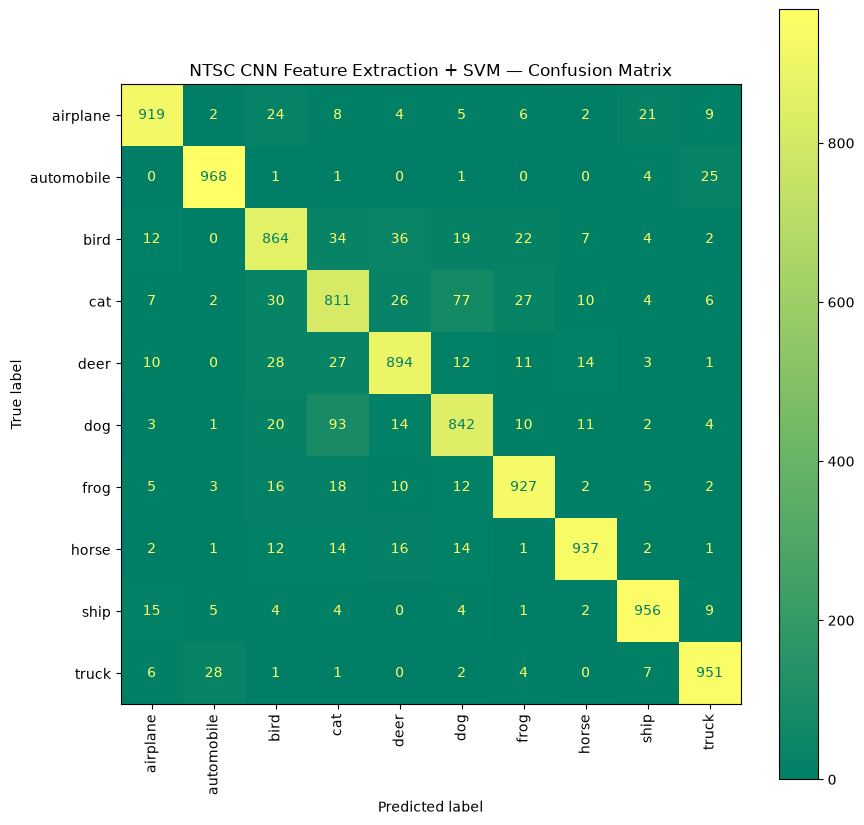

In [44]:
cm = confusion_matrix(
    y_test,
    svm_prediction
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(
    figsize=(10, 10)
)

disp.plot(
    ax=ax,
    xticks_rotation="vertical",
    cmap="summer"
)

plt.title(
    "NTSC CNN Feature Extraction + SVM "
    "— Confusion Matrix"
)

plt.show()

## 11. Beberapa Hasil Prediksi

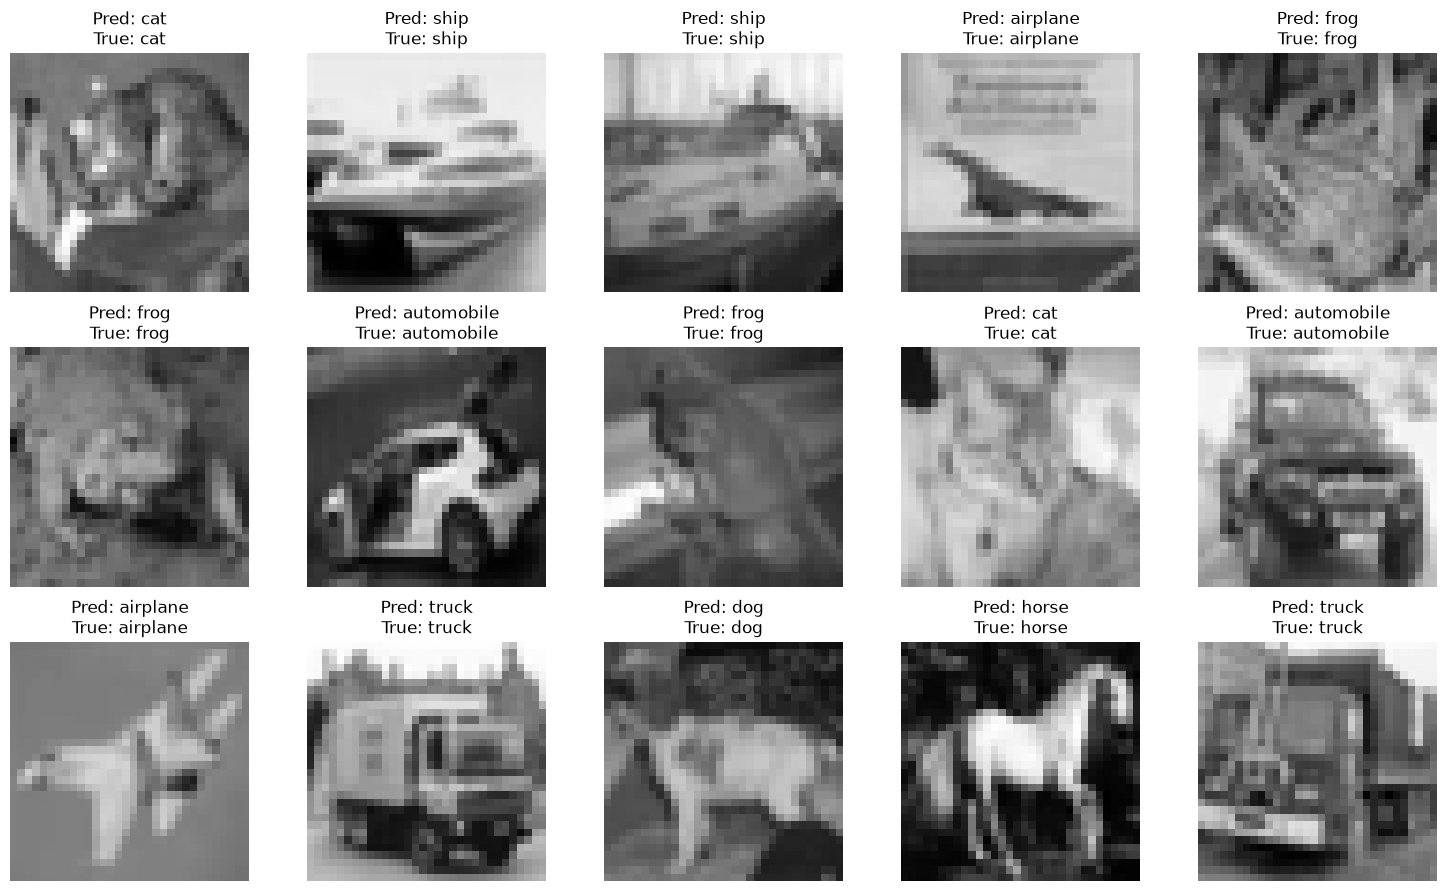

In [45]:
num_rows = 3
num_cols = 5
num_images = (
    num_rows * num_cols
)

plt.figure(figsize=(15, 9))

for i in range(num_images):
    plt.subplot(
        num_rows,
        num_cols,
        i + 1
    )

    plt.imshow(
        X_test[i, :, :, 0],
        cmap="gray",
        vmin=0.0,
        vmax=1.0
    )

    predicted = int(
        svm_prediction[i]
    )

    actual = int(
        y_test[i]
    )

    plt.title(
        f"Pred: {labels[predicted]}\n"
        f"True: {labels[actual]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# NTSC v2 official test complete

The reported scores use saved NTSC v2 CNN and SVM artifacts. No model fitting or parameter selection occurs in this notebook.
